# N1 · 行为克隆 (BC) + 分布漂移

> 配套 11.4-L1 · BC = 从专家 demo 监督学策略 (state→action 回归)。
> 训 BC 让它走到目标; 再看 **demo 太少时的分布漂移** (走到专家没覆盖的状态就乱)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import bc_train as bc
import toy_env as env   # M11.1 共享 (bc_train 已加进 path)
import numpy as np, torch
print('环境 = M11.1 2D 到达任务; BC = state→action 监督回归')

环境 = M11.1 2D 到达任务; BC = state→action 监督回归


## 1. 行为克隆: 从专家 demo 监督学策略

In [2]:
torch.manual_seed(0)
S, A = env.make_demos(n=200, seed=0)
print(f'专家 demo: {len(S)} 个 (state, action) 对')
model = bc.build_bc_policy()
losses = bc.train_bc(model, S, A, epochs=300)
sr = env.eval_policy(bc.bc_policy_fn(model), n_episodes=200)
print(f'BC 训练 loss {losses[0]:.3f} → {losses[-1]:.3f}; 成功率 {sr:.2f}')

专家 demo: 1727 个 (state, action) 对


BC 训练 loss 0.499 → 0.031; 成功率 0.94


## 2. BC 策略 rollout (学会了模仿专家朝目标走)

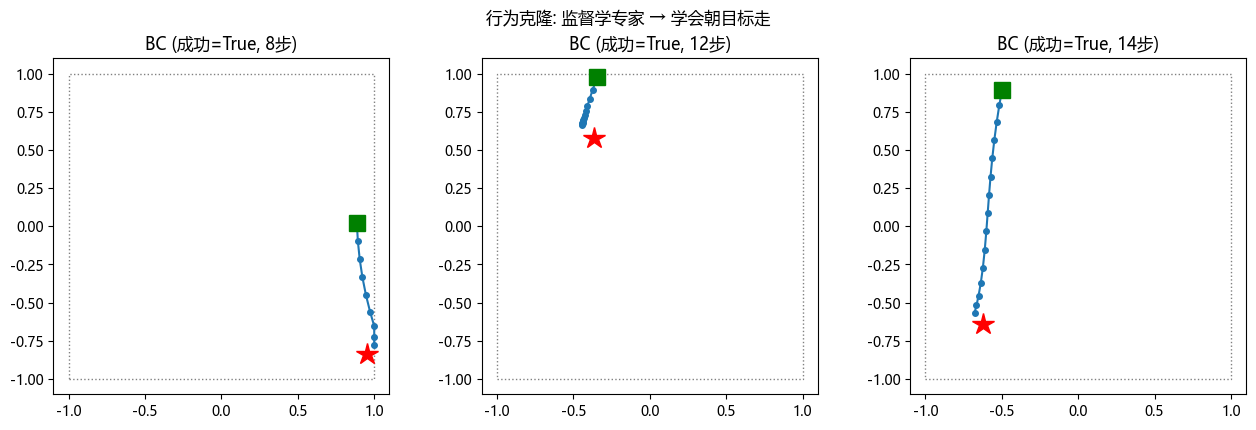

In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
pol = bc.bc_policy_fn(model)
fig, axes = plt.subplots(1,3,figsize=(13,4.2))
for ax, seed in zip(axes, [4,8,12]):
    ok,steps,traj = env.rollout(pol, seed=seed, record=True); traj=np.array(traj)
    ax.plot(traj[:,0],traj[:,1],'-o',ms=4); ax.plot(traj[0,0],traj[0,1],'gs',ms=12); ax.plot(traj[0,2],traj[0,3],'r*',ms=16)
    ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
    ax.set_title(f'BC (成功={ok}, {steps}步)'); ax.set_aspect('equal')
plt.suptitle('行为克隆: 监督学专家 → 学会朝目标走'); plt.tight_layout(); plt.show()

## 3. 分布漂移: demo 太少 vs 充足

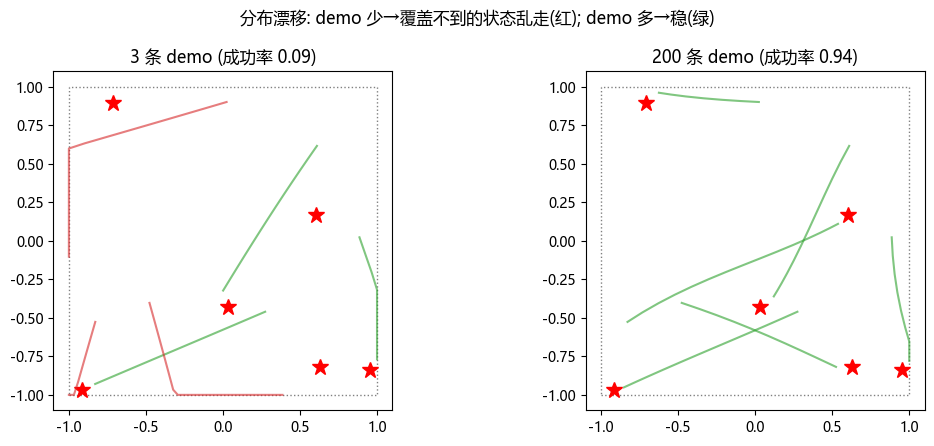

→ demo 太少, BC 在专家没覆盖的状态没学过 → 漂移/失败 (L1 复合误差)。解法: 更多更广数据 (L3)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
for ax, ndemo in zip(axes, [3, 200]):
    Sd, Ad = env.make_demos(n=ndemo, seed=0)
    m = bc.build_bc_policy(seed=0); bc.train_bc(m, Sd, Ad, epochs=300, seed=0)
    p = bc.bc_policy_fn(m); sr = env.eval_policy(p, n_episodes=200)
    for seed in range(6):
        ok,steps,traj = env.rollout(p, seed=seed, record=True); traj=np.array(traj)
        ax.plot(traj[:,0],traj[:,1],'-',alpha=0.6,color='C2' if ok else 'C3')
        ax.plot(traj[0,2],traj[0,3],'r*',ms=12)
    ax.add_patch(plt.Rectangle((-1,-1),2,2,fill=False,ls=':',ec='gray'))
    ax.set_title(f'{ndemo} 条 demo (成功率 {sr:.2f})'); ax.set_aspect('equal')
plt.suptitle('分布漂移: demo 少→覆盖不到的状态乱走(红); demo 多→稳(绿)'); plt.tight_layout(); plt.show()
print('→ demo 太少, BC 在专家没覆盖的状态没学过 → 漂移/失败 (L1 复合误差)。解法: 更多更广数据 (L3)。')

## 4. 反思
你做了行为克隆并看到分布漂移。带走:
- **BC = 监督学专家** (state→action), 机器人训练的基础 (你最熟的范式)。
- **分布漂移**: 偏出专家覆盖的状态就乱 (复合误差, 同 M13.5 误差累积)。
- 解法主力 = **数据 scaling** (更多更广 demo, N2 量化)。
下一步 N2: 数据量 vs 成功率曲线 (scaling)。